# Part A : Question 2: Logistic Regression from Scratch with ROC-AUC 

In [24]:
import pandas as pd 

df = pd.read_csv('heart.csv')

In [25]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [26]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [27]:

import numpy as np
import pandas as pd


In [28]:
X = df.drop("target", axis=1).values
y = df["target"].values.reshape(-1, 1)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (1025, 13)
Shape of y: (1025, 1)


In [29]:
def normalize(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    return (X - mean) / std

X = normalize(X)


In [30]:
def train_test_split(X, y, test_size=0.2):
    np.random.seed(42)
    indices = np.random.permutation(len(X))
    test_count = int(len(X) * test_size)

    test_idx = indices[:test_count]
    train_idx = indices[test_count:]

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

X_train, X_test, y_train, y_test = train_test_split(X, y)


 Implement from scratch:

Sigmoid Function

In [31]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


Binary cross-entropy loss

In [32]:
def binary_cross_entropy(y, y_hat):
    epsilon = 1e-9  
    y_hat = np.clip(y_hat, epsilon, 1 - epsilon)
    loss = -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
    return loss


Gradient descent

In [33]:
def train_logistic_regression(X, y, lr=0.01, epochs=2000):
    n_samples, n_features = X.shape

 
    W = np.zeros((n_features, 1))
    b = 0

    losses = []

    for i in range(epochs):
        z = np.dot(X, W) + b
        y_hat = sigmoid(z)

 
        loss = binary_cross_entropy(y, y_hat)
        losses.append(loss)

    
        dw = (1 / n_samples) * np.dot(X.T, (y_hat - y))
        db = (1 / n_samples) * np.sum(y_hat - y)

  
        W = W - lr * dw
        b = b - lr * db

        if i % 200 == 0:
            print(f"Epoch {i}, Loss: {loss:.4f}")

    return W, b, losses


 Train your model and predict probabilities.

training the model

In [34]:
W, b, losses = train_logistic_regression(X_train, y_train, lr=0.01, epochs=3000)


Epoch 0, Loss: 0.6931
Epoch 200, Loss: 0.4337
Epoch 400, Loss: 0.3826
Epoch 600, Loss: 0.3625
Epoch 800, Loss: 0.3520
Epoch 1000, Loss: 0.3458
Epoch 1200, Loss: 0.3417
Epoch 1400, Loss: 0.3388
Epoch 1600, Loss: 0.3368
Epoch 1800, Loss: 0.3353
Epoch 2000, Loss: 0.3342
Epoch 2200, Loss: 0.3333
Epoch 2400, Loss: 0.3326
Epoch 2600, Loss: 0.3320
Epoch 2800, Loss: 0.3316


In [35]:
def predict_proba(X, W, b):
    z = np.dot(X, W) + b
    return sigmoid(z)

y_test_prob = predict_proba(X_test, W, b)


In [36]:
def predict(y_prob, threshold=0.5):
    return (y_prob >= threshold).astype(int)

y_test_pred = predict(y_test_prob)


Implement manually:

Confusion Matrix

In [37]:
def confusion_matrix(y_true, y_pred):
    TP = TN = FP = FN = 0
    
    for i in range(len(y_true)):
        if y_true[i] == 1 and y_pred[i] == 1:
            TP += 1
        elif y_true[i] == 0 and y_pred[i] == 0:
            TN += 1
        elif y_true[i] == 0 and y_pred[i] == 1:
            FP += 1
        elif y_true[i] == 1 and y_pred[i] == 0:
            FN += 1
            
    return TP, TN, FP, FN


TP, TN, FP, FN = confusion_matrix(y_test.flatten(), y_test_pred.flatten())

print("Confusion Matrix:")
print(f"TP: {TP}, TN: {TN}, FP: {FP}, FN: {FN}")


Confusion Matrix:
TP: 91, TN: 71, FP: 31, FN: 12


Precision, Recall, F1-score

In [22]:
def precision(TP, FP):
    return TP / (TP + FP + 1e-9)

print("Precision:", precision(TP, FP))


Precision: 0.7459016393381483


In [23]:
def recall(TP, FN):
    return TP / (TP + FN + 1e-9)

print("Recall:", recall(TP, FN))


Recall: 0.8834951456224903


In [38]:
def f1_score(precision, recall):
    return 2 * (precision * recall) / (precision + recall + 1e-9)

P = precision(TP, FP)
R = recall(TP, FN)

print("F1 Score:", f1_score(P, R))


F1 Score: 0.8088888883852643


ROC

In [39]:
def roc_curve(y_true, y_prob, thresholds=np.linspace(0,1,100)):
    TPR = []
    FPR = []

    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)

        TP, TN, FP, FN = confusion_matrix(y_true.flatten(), y_pred.flatten())

        tpr = TP / (TP + FN + 1e-9)
        fpr = FP / (FP + TN + 1e-9)

        TPR.append(tpr)
        FPR.append(fpr)

    return FPR, TPR


AUC

In [40]:
def auc(FPR, TPR):
    auc_value = 0
    for i in range(1, len(FPR)):
        auc_value += (FPR[i] - FPR[i-1]) * (TPR[i] + TPR[i-1]) / 2
    return abs(auc_value)


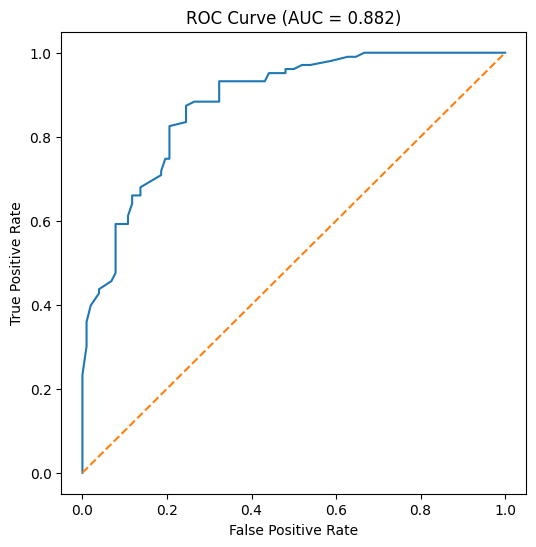

AUC Score: 0.881543879670596


In [41]:
import matplotlib.pyplot as plt

FPR, TPR = roc_curve(y_test, y_test_prob)
auc_value = auc(FPR, TPR)

plt.figure(figsize=(6,6))
plt.plot(FPR, TPR)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {auc_value:.3f})")
plt.show()

print("AUC Score:", auc_value)


Add L2 regularization and analyze its impact on overfitting.

In [42]:
def binary_cross_entropy_l2(y, y_hat, W, lambda_reg):
    epsilon = 1e-9
    y_hat = np.clip(y_hat, epsilon, 1 - epsilon)
    bce = -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
    l2_penalty = (lambda_reg / (2 * len(y))) * np.sum(W ** 2)
    return bce + l2_penalty


In [43]:
def train_logistic_regression_l2(X, y, lr=0.01, epochs=2000, lambda_reg=0.1):
    n_samples, n_features = X.shape
    
    W = np.zeros((n_features, 1))
    b = 0
    losses = []

    for i in range(epochs):
        z = np.dot(X, W) + b
        y_hat = sigmoid(z)

        loss = binary_cross_entropy_l2(y, y_hat, W, lambda_reg)
        losses.append(loss)

        dw = (1 / n_samples) * np.dot(X.T, (y_hat - y)) + (lambda_reg / n_samples) * W
        db = (1 / n_samples) * np.sum(y_hat - y)

        W = W - lr * dw
        b = b - lr * db

        if i % 200 == 0:
            print(f"[L2] Epoch {i}, Loss: {loss:.4f}")

    return W, b, losses


In [44]:
W_l2, b_l2, losses_l2 = train_logistic_regression_l2(X_train, y_train, lr=0.01, epochs=3000, lambda_reg=0.5)


[L2] Epoch 0, Loss: 0.6931
[L2] Epoch 200, Loss: 0.4339
[L2] Epoch 400, Loss: 0.3830
[L2] Epoch 600, Loss: 0.3631
[L2] Epoch 800, Loss: 0.3527
[L2] Epoch 1000, Loss: 0.3466
[L2] Epoch 1200, Loss: 0.3426
[L2] Epoch 1400, Loss: 0.3398
[L2] Epoch 1600, Loss: 0.3378
[L2] Epoch 1800, Loss: 0.3363
[L2] Epoch 2000, Loss: 0.3352
[L2] Epoch 2200, Loss: 0.3344
[L2] Epoch 2400, Loss: 0.3337
[L2] Epoch 2600, Loss: 0.3332
[L2] Epoch 2800, Loss: 0.3328


predicting againn

In [46]:
y_test_prob_l2 = predict_proba(X_test, W_l2, b_l2)
y_test_pred_l2 = predict(y_test_prob_l2)


calculating matrix with the pre written function 

In [47]:
TP, TN, FP, FN = confusion_matrix(y_test.flatten(), y_test_pred_l2.flatten())

print("Accuracy with L2:", accuracy(TP, TN, FP, FN))
print("Precision with L2:", precision(TP, FP))
print("Recall with L2:", recall(TP, FN))

P = precision(TP, FP)
R = recall(TP, FN)
print("F1 Score with L2:", f1_score(P, R))


Accuracy with L2: 0.7902439024390244
Precision with L2: 0.7459016393381483
Recall with L2: 0.8834951456224903
F1 Score with L2: 0.8088888883852643


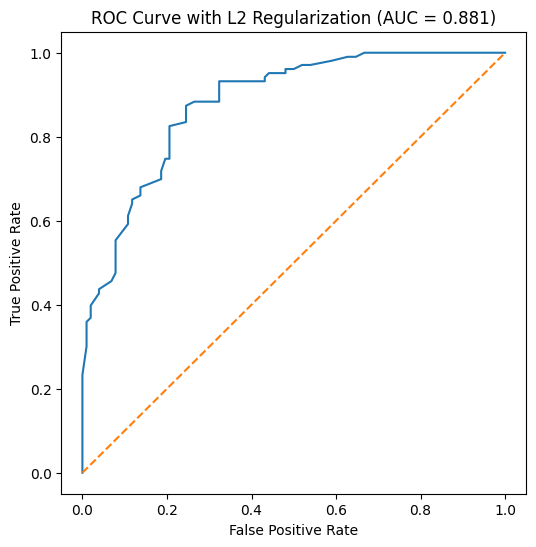

AUC with L2 Regularization: 0.8805444507728428


In [48]:
FPR_l2, TPR_l2 = roc_curve(y_test, y_test_prob_l2)
auc_l2 = auc(FPR_l2, TPR_l2)

plt.figure(figsize=(6,6))
plt.plot(FPR_l2, TPR_l2)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve with L2 Regularization (AUC = {auc_l2:.3f})")
plt.show()

print("AUC with L2 Regularization:", auc_l2)


# PART B :Question 3: Hypothesis Testing + ML Decision Making

given part : An EdTech company tests a new teaching method. The results are:
Group A (Old method): Mean = 65, Std = 8, n = 100
Group B (New method): Mean = 68, Std = 9, n = 100

1. Null and Alternate Hypothesis  

We want to check the new teaching method is better or not.  

Let  
meanA = mean of old method  
meanB = mean of new method  

Null Hypothesis (h0):  
meanB = meanA  
This means new method and old method give same result. No improvment.

Alternate Hypothesis (h1):  
meanB > meanA  
This means new teaching method is better and student marks increase.

It is one tailed test because we only want to check improvment, not decrease.

---

2. Z-test or T-test  

We use Z-test.  

Because:  
- Sample size is large (n = 100 for both groups)  
- n is greater than 30 so Z-test is aplicable  
- Data can be assumed normal due to large sample  
- Z-test is simple and reliable  

So Z-test is correct choice here.

---

3. Decision Process at 5% Significance Level  

Significance level sigma = 0.05  

Steps:  
- Take p-value  
- Compare it with 0.05  

Rule:  
- If p-value < 0.05 → reject h0  
- If p-value > 0.05 → accept h0  

This process helps us to decide if result is real or happend by chance.

---

4. Given p-value = 0.03  

p-value = 0.03  
sigma = 0.05  

Since 0.03 < 0.05  

So we reject the Null Hypothesis (h0).  

Final ans:  
New teaching method is statistically significant and better than old method.  
The improvment is real and not random.

---

5. ML Part  

Even if statistical result is good, ML model accuracy can go down.  

Reasons:  

1. Data change  
New teaching method changes student behaviour.  
Old data and new data pattern are not same, so model gets confused.

2. Overfitting  
Model learned too much from old data and cannot generalise well on new data.

3. Feature problem  
Some features which were important before are not useful now.

4. Data quality issue  
New data may contain missing values, noise or different format.

---

How to fix the ML model:  

1. Retrain the model  
Use both old and new data together.

2. Data cleaning  
Remove missing values, normalize data and clean noise.

3. Feature engineering  
Create new features that match the new teaching method.

4. Validation  
Use cross validation to make model more stable.

5. Regularization  
To reduce overfitting problem.

6. Continuous update  
Update model time to time with fresh data.

---